# BGI Spatial Transcriptomics — Variability & EMT Analysis
This notebook:
1. Loads four BGI **tissue** datasets.
2. Summarises overall and tumour‐specific cell‐type composition.
3. Computes gene‐expression variability metrics (`cv`, `nonzero_ratio`).
4. Visualises variability across epithelial / mesenchymal / EMT‐TF gene categories.
5. Runs a **TIC** pseudo‑time analysis (radius sub‑graph) on *B03425E3* and inspects EMT monotonicity.

> **Prerequisites**  
> • Set your **OpenAI key** in `utils.config.API_KEY` (or edit below).


In [2]:
import warnings
warnings.filterwarnings('ignore')

from tic.data import load_bgi_dataset
from tic.metrics import compute_variability
from tic.plotting import plot_variability
from tic.constant import EPITHELIAL_GENES, MESENCHYMAL_GENES, EMT_TF

# ⚠️ Edit here if you keep your key elsewhere
from utils.config import API_KEY

DATA_DIR = '/Users/zhangjiahao/Dataset/BGI'  # ← adjust if needed


## 1. Load datasets

In [7]:
sample_ids = [ 'C03628C1', 'B03425E1', 'B02804B5', 'B03425E3']
adatas = {}
for sid in sample_ids:
    adata = load_bgi_dataset(
        sid,
        data_type='tissue',
        data_dir=DATA_DIR,
        normalize=None,
        log=False,
        min_total_counts_ratio=None,
        llm_model_name='openai',
        llm_kwargs={'api_key': API_KEY, 'mirror': True},
    )
    adatas[sid] = adata
    print(f'{sid}:', adata)


2025-06-12 18:10:53,581 INFO Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/C03628C1/C03628C1_tissue_llm_cell_types.parquet
2025-06-12 18:10:53,581 | INFO     | tic.data.bgi.loader | Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/C03628C1/C03628C1_tissue_llm_cell_types.parquet
2025-06-12 18:10:53,774 INFO Loaded BGI sample C03628C1 (tissue) – 8317 cells × 37513 genes
2025-06-12 18:10:53,774 | INFO     | tic.data.bgi.loader | Loaded BGI sample C03628C1 (tissue) – 8317 cells × 37513 genes
2025-06-12 18:10:53,972 INFO Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/B03425E1/B03425E1_tissue_llm_cell_types.parquet
2025-06-12 18:10:53,972 | INFO     | tic.data.bgi.loader | Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/B03425E1/B03425E1_tissue_llm_cell_types.parquet


C03628C1: AnnData object with n_obs × n_vars = 8317 × 37513
    obs: 'orig.ident', 'x', 'y', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


2025-06-12 18:10:54,179 INFO Loaded BGI sample B03425E1 (tissue) – 12939 cells × 37388 genes
2025-06-12 18:10:54,179 | INFO     | tic.data.bgi.loader | Loaded BGI sample B03425E1 (tissue) – 12939 cells × 37388 genes


B03425E1: AnnData object with n_obs × n_vars = 12939 × 37388
    obs: 'orig.ident', 'x', 'y', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


2025-06-12 18:10:54,454 INFO Running LLM annotation for B02804B5 (tissue) via openai …
2025-06-12 18:10:54,454 | INFO     | tic.data.bgi.loader | Running LLM annotation for B02804B5 (tissue) via openai …
2025-06-12 18:12:19,849 INFO Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B02804B5/B02804B5_tissue_llm_cell_types.parquet
2025-06-12 18:12:19,849 | INFO     | tic.data.bgi.loader | Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B02804B5/B02804B5_tissue_llm_cell_types.parquet
2025-06-12 18:12:22,089 INFO Loaded BGI sample B02804B5 (tissue) – 26194 cells × 25356 genes
2025-06-12 18:12:22,089 | INFO     | tic.data.bgi.loader | Loaded BGI sample B02804B5 (tissue) – 26194 cells × 25356 genes


B02804B5: AnnData object with n_obs × n_vars = 26194 × 25356
    obs: 'orig.ident', 'x', 'y', 'leiden', 'pred_cell_type', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


2025-06-12 18:12:22,647 INFO Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/B03425E3/B03425E3_tissue_llm_cell_types.parquet
2025-06-12 18:12:22,647 | INFO     | tic.data.bgi.loader | Loaded cached cell types from /Users/zhangjiahao/Dataset/BGI/B03425E3/B03425E3_tissue_llm_cell_types.parquet
2025-06-12 18:12:22,771 INFO Loaded BGI sample B03425E3 (tissue) – 10497 cells × 36008 genes
2025-06-12 18:12:22,771 | INFO     | tic.data.bgi.loader | Loaded BGI sample B03425E3 (tissue) – 10497 cells × 36008 genes


B03425E3: AnnData object with n_obs × n_vars = 10497 × 36008
    obs: 'orig.ident', 'x', 'y', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


In [9]:
sample_ids = [ 'C03628C1', 'B03425E1', 'B02804B5', 'B03425E3']
adatas = {}
for sid in sample_ids:
    adata = load_bgi_dataset(
        sid,
        data_type='raw',
        data_dir=DATA_DIR,
        normalize=None,
        log=False,
        min_total_counts_ratio=None,
        llm_model_name='openai',
        llm_kwargs={'api_key': API_KEY, 'mirror': True},
    )
    adatas[sid] = adata
    print(f'{sid}:', adata)


2025-06-12 18:27:23,398 INFO Running LLM annotation for C03628C1 (raw) via openai …
2025-06-12 18:27:23,398 | INFO     | tic.data.bgi.loader | Running LLM annotation for C03628C1 (raw) via openai …
2025-06-12 18:29:34,574 INFO Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/C03628C1/C03628C1_raw_llm_cell_types.parquet
2025-06-12 18:29:34,574 | INFO     | tic.data.bgi.loader | Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/C03628C1/C03628C1_raw_llm_cell_types.parquet
2025-06-12 18:29:37,302 INFO Loaded BGI sample C03628C1 (raw) – 47370 cells × 39357 genes
2025-06-12 18:29:37,302 | INFO     | tic.data.bgi.loader | Loaded BGI sample C03628C1 (raw) – 47370 cells × 39357 genes


C03628C1: AnnData object with n_obs × n_vars = 47370 × 39357
    obs: 'orig.ident', 'x', 'y', 'leiden', 'pred_cell_type', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


2025-06-12 18:29:38,807 INFO Running LLM annotation for B03425E1 (raw) via openai …
2025-06-12 18:29:38,807 | INFO     | tic.data.bgi.loader | Running LLM annotation for B03425E1 (raw) via openai …
2025-06-12 18:31:56,853 INFO Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B03425E1/B03425E1_raw_llm_cell_types.parquet
2025-06-12 18:31:56,853 | INFO     | tic.data.bgi.loader | Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B03425E1/B03425E1_raw_llm_cell_types.parquet
2025-06-12 18:31:58,383 INFO Loaded BGI sample B03425E1 (raw) – 48488 cells × 40264 genes
2025-06-12 18:31:58,383 | INFO     | tic.data.bgi.loader | Loaded BGI sample B03425E1 (raw) – 48488 cells × 40264 genes


B03425E1: AnnData object with n_obs × n_vars = 48488 × 40264
    obs: 'orig.ident', 'x', 'y', 'leiden', 'pred_cell_type', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


2025-06-12 18:31:58,865 INFO Running LLM annotation for B02804B5 (raw) via openai …
2025-06-12 18:31:58,865 | INFO     | tic.data.bgi.loader | Running LLM annotation for B02804B5 (raw) via openai …
2025-06-12 18:34:29,113 INFO Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B02804B5/B02804B5_raw_llm_cell_types.parquet
2025-06-12 18:34:29,113 | INFO     | tic.data.bgi.loader | Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B02804B5/B02804B5_raw_llm_cell_types.parquet
2025-06-12 18:34:29,758 INFO Loaded BGI sample B02804B5 (raw) – 61365 cells × 25781 genes
2025-06-12 18:34:29,758 | INFO     | tic.data.bgi.loader | Loaded BGI sample B02804B5 (raw) – 61365 cells × 25781 genes
2025-06-12 18:34:29,952 INFO Running LLM annotation for B03425E3 (raw) via openai …
2025-06-12 18:34:29,952 | INFO     | tic.data.bgi.loader | Running LLM annotation for B03425E3 (raw) via openai …


B02804B5: AnnData object with n_obs × n_vars = 61365 × 25781
    obs: 'orig.ident', 'x', 'y', 'leiden', 'pred_cell_type', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


2025-06-12 18:36:18,995 INFO Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B03425E3/B03425E3_raw_llm_cell_types.parquet
2025-06-12 18:36:18,995 | INFO     | tic.data.bgi.loader | Saved annotation cache → /Users/zhangjiahao/Dataset/BGI/B03425E3/B03425E3_raw_llm_cell_types.parquet
2025-06-12 18:36:19,991 INFO Loaded BGI sample B03425E3 (raw) – 54664 cells × 38565 genes
2025-06-12 18:36:19,991 | INFO     | tic.data.bgi.loader | Loaded BGI sample B03425E3 (raw) – 54664 cells × 38565 genes


B03425E3: AnnData object with n_obs × n_vars = 54664 × 38565
    obs: 'orig.ident', 'x', 'y', 'leiden', 'pred_cell_type', 'cell_type'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'tissue_id', 'data_level'
    obsm: 'spatial'


### 1.1 Cell‑type composition & tumour subsets

In [4]:
tumour_adatas = {}
for sid, adata in adatas.items():
    vc = adata.obs['cell_type'].value_counts()
    tumour_types = [c for c in vc.index if 'tumor' in c.lower()]
    print(f'\n📊 {sid} – top cell types:\n', vc.head())
    print(f'Tumour‑related types ({len(tumour_types)}): {tumour_types}')
    tumour_adatas[sid] = adata[adata.obs['cell_type'].isin(tumour_types)].copy()



📊 C03628C1 – top cell types:
 cell_type
Endothelial cell             2149
Stromal cell / Fibroblast    1071
Epithelial cell               885
B cell / Plasma cell          857
Pericyte / Stromal cell       329
Name: count, dtype: int64
Tumour‑related types (7): ['Activated epithelial / tumor cell', 'Immediate early gene-active cell (possibly stroma or stress-activated tumor)', 'Immediate early gene-expressing stromal/tumor cell', 'Epithelial / Tumor cell', 'Metabolic / stressed tumor cell', 'Proliferative tumor/epithelial cell', 'Activated stromal/tumor cell']

📊 B03425E1 – top cell types:
 cell_type
Cycling Tumor Cells / Proliferating Epithelial Cells    2615
Basal Epithelial Cells / Squamous Epithelial Cells      1882
Alveolar Type II Epithelial Cells                       1635
Fibroblasts (Collagen-rich)                             1096
Basal Epithelial Cells / Transitional Tumor Cells        962
Name: count, dtype: int64
Tumour‑related types (2): ['Cycling Tumor Cells / Proliferat

## 2. Gene‑expression variability

In [5]:
# Compute CV & non‑zero ratio for each (full vs tumour)
variability_full  = {}
variability_tumor = {}
for sid in sample_ids:
    variability_full[sid]  = compute_variability(adatas[sid], metrics=['cv', 'nonzero_ratio'])
    variability_tumor[sid] = compute_variability(tumour_adatas[sid], metrics=['cv', 'nonzero_ratio'])


### 2.1 Variability plots

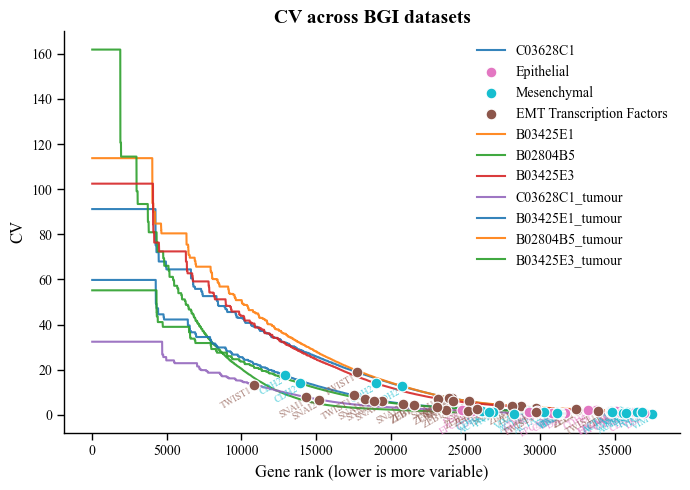

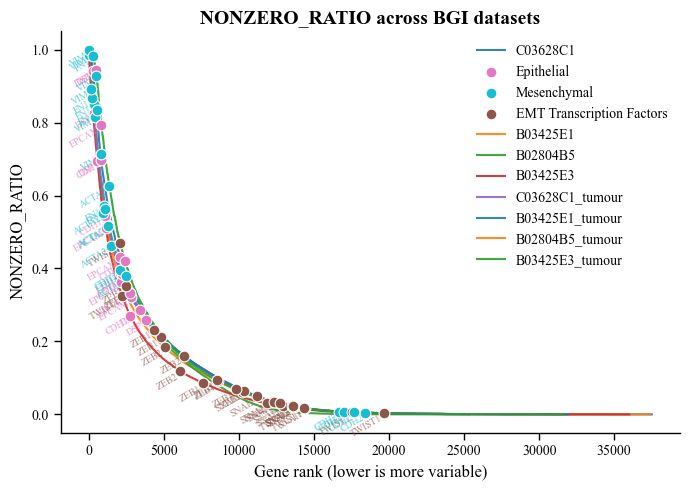

In [6]:
gene_categories = {
    'Epithelial': EPITHELIAL_GENES,
    'Mesenchymal': MESENCHYMAL_GENES,
    'EMT Transcription Factors': EMT_TF,
}

for metric in ['cv', 'nonzero_ratio']:
    plot_variability(
        variability={
            **{sid: variability_full[sid] for sid in sample_ids},
            **{sid + '_tumour': variability_tumor[sid] for sid in sample_ids},
        },
        metric=metric,
        gene_categories=gene_categories,
        title=f'{metric.upper()} across BGI datasets',
        annotate_emt=True,
    )
